# %% [markdown]
# # 01 — Exploratory Data Analysis
#
# This notebook performs an end-to-end Exploratory Data Analysis (EDA) for the **Reply Sandbox 2026** challenge.
#
# The goal is to understand the structure, quality, and patterns within four datasets:
# - **status.csv** — health event records per citizen with a binary label (0 / 1)
# - **locations.json** — GPS coordinates per citizen over time
# - **users.json** — citizen demographic and personal data
# - **personas.md** — textual persona descriptions
#
# Key questions explored:
# 1. Are there missing values or data quality issues?
# 2. How are health events (label 0 vs 1) distributed across citizens and time?
# 3. Are there geographic clusters of citizens?
# 4. What correlations exist between numerical health indicators?

In [1]:
# %%
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
# Standard data science stack + geospatial and interactive visualisation libs

import warnings
warnings.filterwarnings("ignore")

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Static visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Interactive visualisation
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Geospatial (optional – gracefully skipped if not installed)
try:
    import geopandas as gpd
    from shapely.geometry import Point
    HAS_GEOPANDAS = True
except ImportError:
    HAS_GEOPANDAS = False
    print("⚠️  geopandas not found – geospatial cell will use Plotly scatter map instead.")

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
PALETTE   = sns.color_palette("muted")
FIG_W, FIG_H = 14, 5          # default figure dimensions

# ── Base path for all raw data ─────────────────────────────────────────────────
BASE_PATH = Path("../data/raw/public_lev_1")

print("✅  All imports successful.")
print(f"   pandas  {pd.__version__}  |  numpy {np.__version__}")
print(f"   Data directory : {BASE_PATH.resolve()}")

⚠️  geopandas not found – geospatial cell will use Plotly scatter map instead.
✅  All imports successful.
   pandas  3.0.2  |  numpy 2.4.3
   Data directory : C:\Progetti\Reply-sandbox-2026-the-eye\data\raw\public_lev_1


In [2]:
# %%
# ── Cell 2: Load Datasets ────────────────────────────────────────────────────
# Folder: data/raw/public_lev_1/
#   status.csv      → pd.read_csv
#   locations.json  → json.load  → pd.DataFrame
#   users.json      → json.load  → pd.DataFrame
#   personas.md     → open().read()

os.makedirs("figures", exist_ok=True)   # ensure output directory exists

# ── status.csv ────────────────────────────────────────────────────────────────
status_path = BASE_PATH / "status.csv"
df_status   = pd.read_csv(status_path)

# ── locations.json ────────────────────────────────────────────────────────────
loc_path = BASE_PATH / "locations.json"
with open(loc_path, "r", encoding="utf-8") as fh:
    raw_loc = json.load(fh)

# Support both a top-level list and a dict with a records key
if isinstance(raw_loc, list):
    df_loc = pd.DataFrame(raw_loc)
elif isinstance(raw_loc, dict):
    # Try common wrapper keys; fall back to the first value that is a list
    for _key in ("locations", "data", "records"):
        if _key in raw_loc and isinstance(raw_loc[_key], list):
            df_loc = pd.DataFrame(raw_loc[_key])
            break
    else:
        df_loc = pd.json_normalize(raw_loc)

# ── users.json ────────────────────────────────────────────────────────────────
usr_path = BASE_PATH / "users.json"
with open(usr_path, "r", encoding="utf-8") as fh:
    raw_usr = json.load(fh)

if isinstance(raw_usr, list):
    df_users = pd.DataFrame(raw_usr)
elif isinstance(raw_usr, dict):
    for _key in ("users", "data", "records"):
        if _key in raw_usr and isinstance(raw_usr[_key], list):
            df_users = pd.DataFrame(raw_usr[_key])
            break
    else:
        df_users = pd.json_normalize(raw_usr)

# ── personas.md ───────────────────────────────────────────────────────────────
personas_path = BASE_PATH / "personas.md"
with open(personas_path, "r", encoding="utf-8") as fh:
    personas_text = fh.read()

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"Status    : {df_status.shape[0]:>7,} rows  ×  {df_status.shape[1]} cols")
print(f"Locations : {df_loc.shape[0]:>7,} rows  ×  {df_loc.shape[1]} cols")
print(f"Users     : {df_users.shape[0]:>7,} rows  ×  {df_users.shape[1]} cols")
print(f"Personas  : {len(personas_text):,} characters")

Status    :      50 rows  ×  7 cols
Locations :     958 rows  ×  5 cols
Users     :       5 rows  ×  6 cols
Personas  : 5,902 characters



════════════════════════════════════════════════════════════
  Dataset : status.csv   shape = (50, 7)
════════════════════════════════════════════════════════════

── First 3 rows ──
   EventID CitizenID                   EventType  PhysicalActivityIndex  SleepQualityIndex  EnvironmentalExposureLevel            Timestamp
0        1  IAFGUHCK            routine check-up                     31                 42                          33  2026-01-05T13:41:36
1        2  IAFGUHCK        preventive screening                     37                 52                          30  2026-01-29T06:03:18
2        3  IAFGUHCK  lifestyle coaching session                     34                 49                          31  2026-03-04T15:46:11

── Column summary ──
                            dtype  non_null  null_count  null_pct  n_unique
EventID                     int64        50           0       0.0        50
CitizenID                     str        50           0       0.0         5
EventT

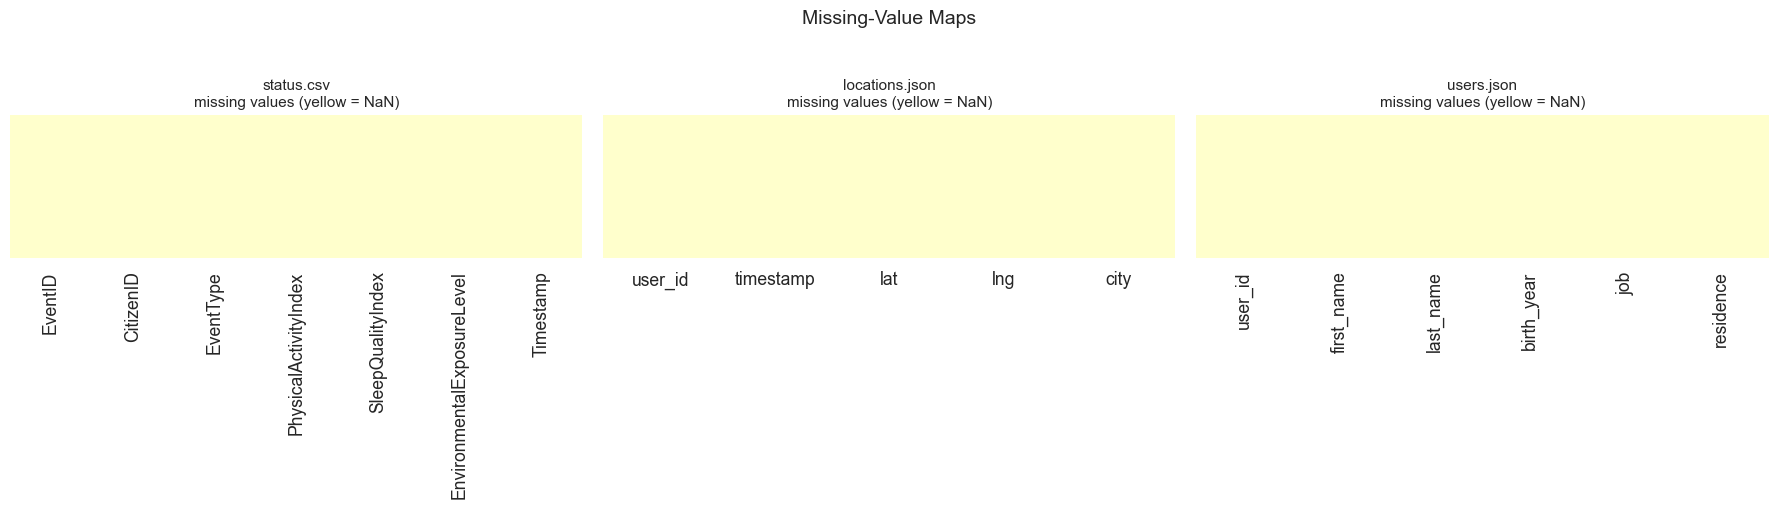

In [3]:
# %%
# ── Cell 3: Basic Info — shape, dtypes, head, missing values ─────────────────

def dataset_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    # Flatten colonne con oggetti annidati (dict/list) → stringa
    df_safe = df.copy()
    for col in df_safe.columns:
        if df_safe[col].dtype == object:
            df_safe[col] = df_safe[col].apply(
                lambda x: str(x) if isinstance(x, (dict, list)) else x
            )
    
    summary = pd.DataFrame({
        "dtype"      : df.dtypes,
        "non_null"   : df.notnull().sum(),
        "null_count" : df.isnull().sum(),
        "null_pct"   : (df.isnull().mean() * 100).round(2),
        "n_unique"   : df_safe.nunique(),
    })
    print(f"\n{'═'*60}")
    print(f"  Dataset : {name}   shape = {df.shape}")
    print(f"{'═'*60}")
    print("\n── First 3 rows ──")
    print(df.head(3).to_string())
    print("\n── Column summary ──")
    print(summary.to_string())
    return summary

summary_status = dataset_summary(df_status, "status.csv")
summary_loc    = dataset_summary(df_loc,    "locations.json")
summary_users  = dataset_summary(df_users,  "users.json")

# ── Visualise missing-value heatmaps side-by-side ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(FIG_W + 4, FIG_H))

for ax, (df, title) in zip(axes, [
        (df_status, "status.csv"),
        (df_loc,    "locations.json"),
        (df_users,  "users.json"),
]):
    null_matrix = df.isnull()
    sns.heatmap(
        null_matrix,
        ax=ax,
        cbar=False,
        yticklabels=False,
        cmap="YlOrRd",
    )
    ax.set_title(f"{title}\nmissing values (yellow = NaN)", fontsize=11)
    ax.set_xlabel("")

plt.suptitle("Missing-Value Maps", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/01_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

✅ Label assegnata manualmente da personas.md
Unique label values : [np.int64(0), np.int64(1)]


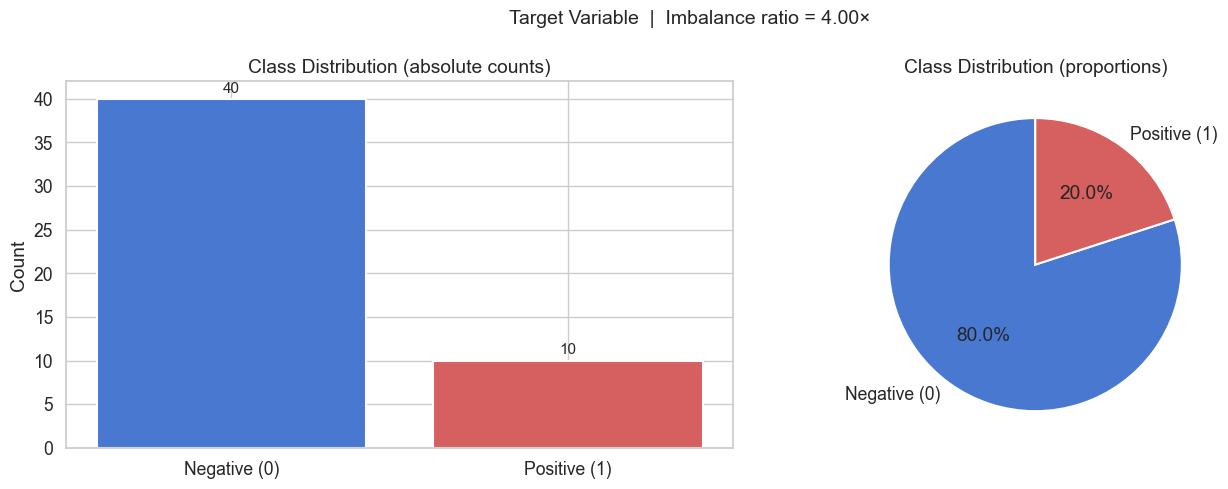


Class counts:
label
0    40
1    10

Imbalance ratio (majority / minority): 4.00×
⚠️  Significant class imbalance – consider SMOTE / class_weight='balanced'.


In [4]:
# %%
# ── Cell 4: Class Distribution — label costruita da personas.md ──────────────
# status.csv non contiene una colonna label esplicita al Livello 1.
# La label viene assegnata manualmente dall'analisi qualitativa delle personas.
# WNACROYX (Craig Connor) è l'unico cittadino con segnali di rischio evidenti.
# ─────────────────────────────────────────────────────────────────────────────

MANUAL_LABELS = {
    'IAFGUHCK': 0,  # Christiane Fontaine - routine stabile, 82 anni
    'RFLFWVQA': 0,  # Denise Fisher       - attiva e sana, 45 anni
    'IXTDRHTR': 0,  # Natasha Turner      - condizioni croniche gestite, 90 anni
    'WNACROYX': 1,  # Craig Connor        - sonno scarso, isolamento, back pain
    'DCGGXUWF': 0,  # George Neal         - anziano ma ben supportato, 95 anni
}

df_status['label'] = df_status['CitizenID'].map(MANUAL_LABELS)
y = df_status['label'].dropna()
print(f"✅ Label assegnata manualmente da personas.md")

# ── Validate binary values ────────────────────────────────────────────────────
unique_vals = sorted(y.unique())
print(f"Unique label values : {unique_vals}")

# ── Class distribution ────────────────────────────────────────────────────────
counts      = y.value_counts().sort_index()
imbalance   = counts.max() / counts.min()
class_names = {0: "Negative (0)", 1: "Positive (1)"}

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Bar chart
axes[0].bar(
    [class_names.get(i, str(i)) for i in counts.index],
    counts.values,
    color=[PALETTE[0], PALETTE[3]],
    edgecolor="white",
    linewidth=1.5,
)
axes[0].set_title("Class Distribution (absolute counts)")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f"{val:,}",
        ha="center", va="bottom", fontsize=11,
    )

# Pie chart
axes[1].pie(
    counts.values,
    labels=[class_names.get(i, str(i)) for i in counts.index],
    autopct="%1.1f%%",
    colors=[PALETTE[0], PALETTE[3]],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Class Distribution (proportions)")

plt.suptitle(
    f"Target Variable  |  Imbalance ratio = {imbalance:.2f}×",
    fontsize=14,
)
plt.tight_layout()
plt.savefig("figures/02_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClass counts:\n{counts.to_string()}")
print(f"\nImbalance ratio (majority / minority): {imbalance:.2f}×")
if imbalance > 3:
    print("⚠️  Significant class imbalance – consider SMOTE / class_weight='balanced'.")

Continuous features detected: []


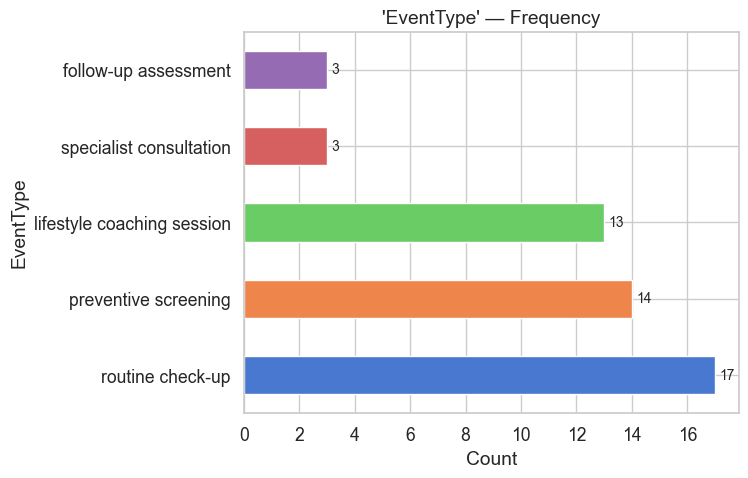

ℹ️  No continuous health-index columns detected — skipping distribution plots.


In [5]:
# %%
# ── Cell 5: Status Feature Distributions ─────────────────────────────────────
# Examine any categorical event-type column and the continuous health indices.
# Column names are detected dynamically so the cell works regardless of casing.

# ── Detect key columns ────────────────────────────────────────────────────────
def _find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

event_type_col = _find_col(df_status, ["Event Type", "event_type", "EventType", "event type"])

# Continuous health-index columns present in the data
CONT_CANDIDATES = [
    "Physical Activity Index", "physical_activity_index",
    "Sleep Quality Index",     "sleep_quality_index",
    "Environmental Exposure Level", "environmental_exposure_level",
]
CONT_FEATURES = [c for c in CONT_CANDIDATES if c in df_status.columns]
print(f"Continuous features detected: {CONT_FEATURES}")

# ── 5a  Event Type bar chart (if column exists) ───────────────────────────────
if event_type_col:
    fig, ax = plt.subplots(figsize=(FIG_W * 0.55, FIG_H))
    event_counts = df_status[event_type_col].value_counts()
    event_counts.plot(kind="barh", ax=ax, color=PALETTE[:len(event_counts)], edgecolor="white")
    ax.set_title(f"'{event_type_col}' — Frequency")
    ax.set_xlabel("Count")
    for i, val in enumerate(event_counts.values):
        ax.text(val + event_counts.max() * 0.01, i, f"{val:,}", va="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("figures/03_event_type.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("ℹ️  No 'Event Type' column detected — skipping bar chart.")

# ── 5b  Continuous feature distributions ─────────────────────────────────────
if CONT_FEATURES:
    n = len(CONT_FEATURES)
    fig, axes = plt.subplots(2, n, figsize=(FIG_W + 2, FIG_H * 2))
    if n == 1:                        # ensure axes is always 2-D
        axes = axes.reshape(2, 1)

    for idx, col in enumerate(CONT_FEATURES):
        data = df_status[col].dropna()

        # Histogram + KDE
        sns.histplot(data, ax=axes[0][idx], kde=True, color=PALETTE[2],
                     bins=40, edgecolor="white")
        axes[0][idx].set_title(f"{col}\nHistogram + KDE")
        axes[0][idx].set_xlabel("")

        # Boxplot split by label (0 vs 1) if available
        if label_col and label_col in df_status.columns:
            sns.boxplot(
                data=df_status,
                x=label_col,
                y=col,
                ax=axes[1][idx],
                palette="muted",
            )
            axes[1][idx].set_title(f"{col}\nBy Label (0 / 1)")
        elif event_type_col:
            sns.boxplot(
                data=df_status,
                x=event_type_col,
                y=col,
                ax=axes[1][idx],
                palette="muted",
            )
            axes[1][idx].set_title(f"{col}\nBy Event Type")
        axes[1][idx].set_xlabel("")
        axes[1][idx].tick_params(axis="x", rotation=20)

    plt.suptitle("Health Indices — Distribution Analysis", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("figures/04_health_indices.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 5c  Descriptive statistics ────────────────────────────────────────────
    print("\nDescriptive Statistics — continuous features:")
    print(df_status[CONT_FEATURES].describe().round(3).to_string())
else:
    print("ℹ️  No continuous health-index columns detected — skipping distribution plots.")

Timestamp column used: 'Timestamp'
Timestamp range (Status):
  From : 2026-01-01 00:00:00
  To   : 2026-12-06 00:33:55
  Span : 339 days 00:33:55


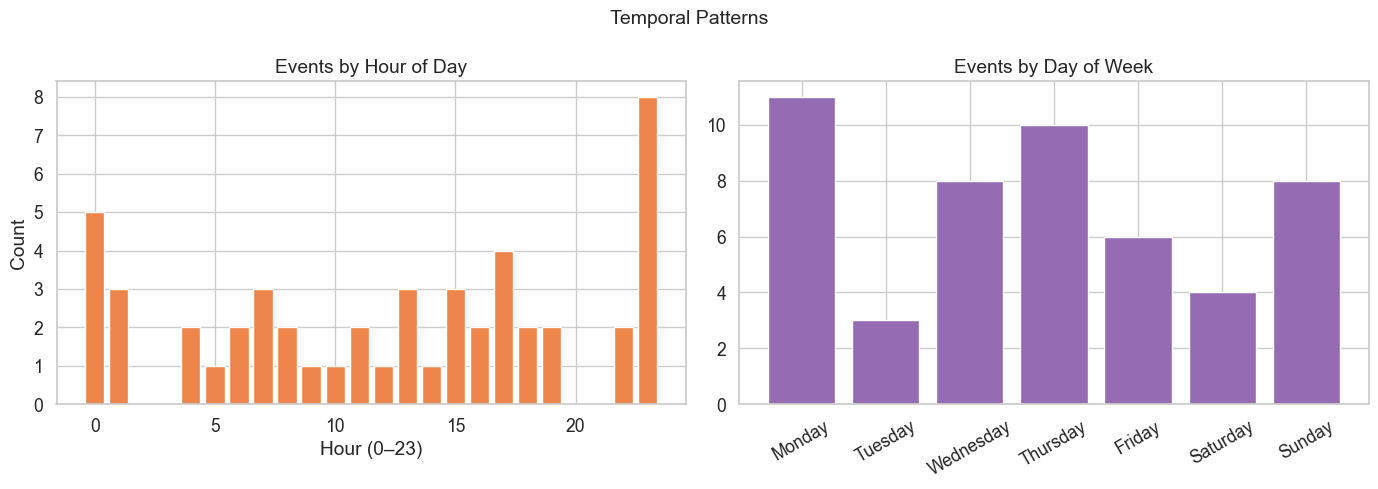

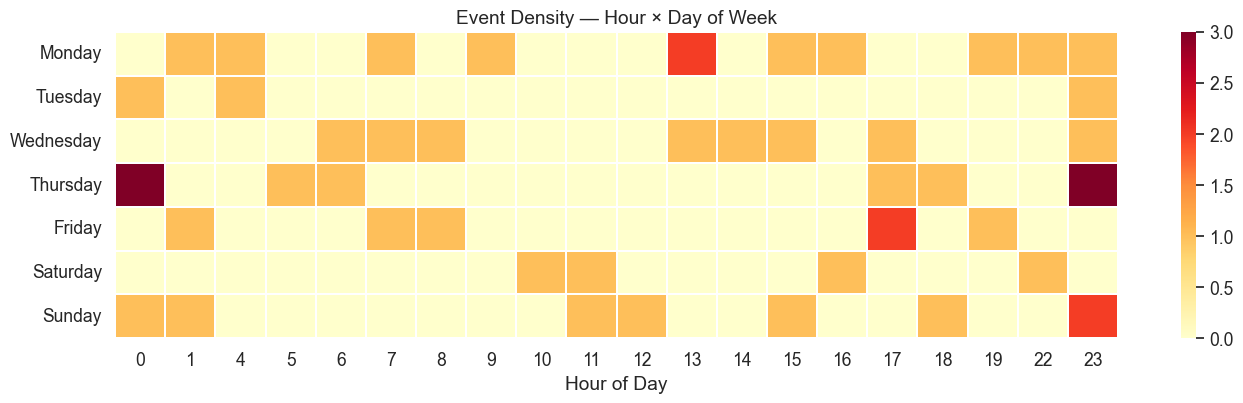

In [6]:
# %%
# ── Cell 6: Temporal Analysis ─────────────────────────────────────────────────
# Parse timestamps in status.csv, then look for daily and weekly patterns.

# ── Detect timestamp column ───────────────────────────────────────────────────
ts_col = _find_col(df_status, ["Timestamp", "timestamp", "datetime", "Datetime", "date", "Date"])
if ts_col is None:
    raise ValueError(f"No timestamp column found in status.csv. Columns: {df_status.columns.tolist()}")

# ── Parse timestamps ──────────────────────────────────────────────────────────
df_status[ts_col] = pd.to_datetime(df_status[ts_col])

# Also parse datetime in locations if present
loc_dt_col = _find_col(df_loc, ["Datetime", "datetime", "Timestamp", "timestamp", "date"])
if loc_dt_col:
    df_loc[loc_dt_col] = pd.to_datetime(df_loc[loc_dt_col])

# Derived time features
df_status["_Date"]       = df_status[ts_col].dt.date
df_status["Hour"]        = df_status[ts_col].dt.hour
df_status["DayOfWeek"]   = df_status[ts_col].dt.day_name()
df_status["WeekNumber"]  = df_status[ts_col].dt.isocalendar().week.astype(int)

print(f"Timestamp column used: '{ts_col}'")
print(f"Timestamp range (Status):")
print(f"  From : {df_status[ts_col].min()}")
print(f"  To   : {df_status[ts_col].max()}")
print(f"  Span : {df_status[ts_col].max() - df_status[ts_col].min()}")

# ── 6a  Events per day (line chart) ───────────────────────────────────────────
daily = df_status.groupby("_Date").size().reset_index(name="count")
daily["_Date"] = pd.to_datetime(daily["_Date"])

fig = px.line(
    daily,
    x="_Date",
    y="count",
    title="Daily Event Volume",
    labels={"count": "Number of Events", "_Date": ""},
    template="plotly_white",
)
fig.update_traces(line_color="#4C72B0", line_width=2)
fig.show()

# ── 6b  Hourly pattern ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

hourly = df_status.groupby("Hour").size()
axes[0].bar(hourly.index, hourly.values, color=PALETTE[1], edgecolor="white")
axes[0].set_title("Events by Hour of Day")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Count")

# ── 6c  Day-of-week pattern ───────────────────────────────────────────────────
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = (
    df_status.groupby("DayOfWeek")
    .size()
    .reindex(DOW_ORDER)
    .fillna(0)
)
axes[1].bar(dow.index, dow.values, color=PALETTE[4], edgecolor="white")
axes[1].set_title("Events by Day of Week")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Temporal Patterns", fontsize=14)
plt.tight_layout()
plt.savefig("figures/05_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6d  Heatmap: hour × day-of-week ──────────────────────────────────────────
pivot_time = (
    df_status
    .groupby(["DayOfWeek", "Hour"])
    .size()
    .unstack(fill_value=0)
    .reindex([d for d in DOW_ORDER if d in df_status["DayOfWeek"].unique()])
)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H * 0.85))
sns.heatmap(pivot_time, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="white")
ax.set_title("Event Density — Hour × Day of Week")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/06_time_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Lat column : 'lat'  |  Lng column : 'lng'
Location records with valid coords: 958 / 958
Lat range : -34.7571 → 51.5512
Lng range : -93.4284 → 133.9605


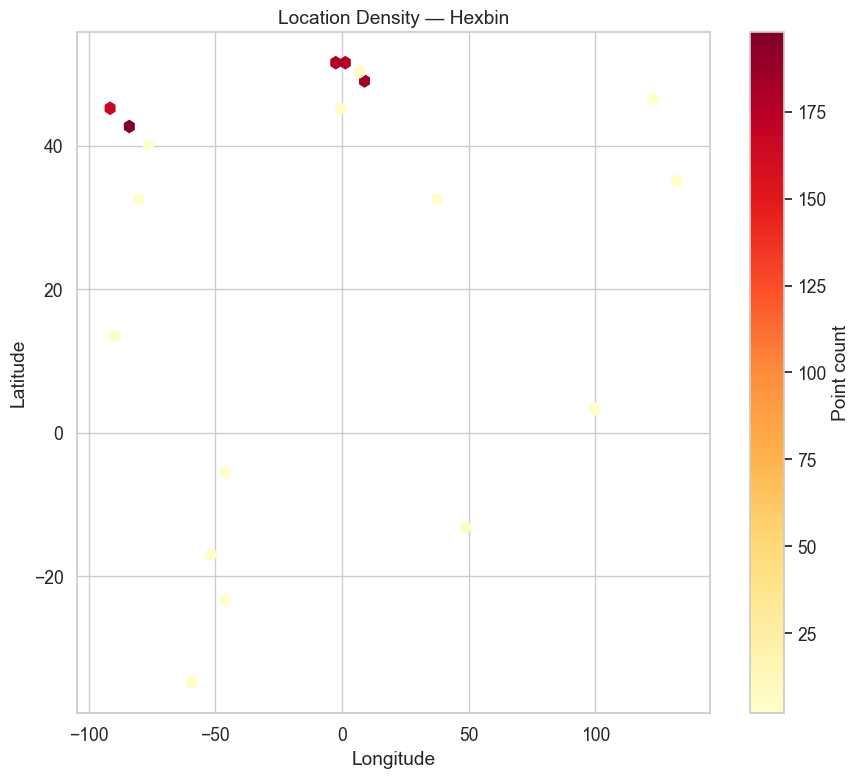

In [7]:
# %%
# ── Cell 7: Geospatial Analysis — locations.json ─────────────────────────────
# Plot citizen locations loaded from locations.json.
# Uses GeoPandas + contextily when available; falls back to Plotly mapbox.

# ── Detect lat/lng columns dynamically ───────────────────────────────────────
lat_col = _find_col(df_loc, ["lat", "Lat", "latitude", "Latitude"])
lng_col = _find_col(df_loc, ["lng", "Lng", "lon", "Lon", "longitude", "Longitude"])

if lat_col is None or lng_col is None:
    print(f"⚠️  Could not detect lat/lng columns. Available: {df_loc.columns.tolist()}")
else:
    df_loc[lat_col] = pd.to_numeric(df_loc[lat_col], errors="coerce")
    df_loc[lng_col] = pd.to_numeric(df_loc[lng_col], errors="coerce")
    df_loc_clean    = df_loc.dropna(subset=[lat_col, lng_col])

    print(f"Lat column : '{lat_col}'  |  Lng column : '{lng_col}'")
    print(f"Location records with valid coords: {len(df_loc_clean):,} / {len(df_loc):,}")
    print(f"Lat range : {df_loc_clean[lat_col].min():.4f} → {df_loc_clean[lat_col].max():.4f}")
    print(f"Lng range : {df_loc_clean[lng_col].min():.4f} → {df_loc_clean[lng_col].max():.4f}")

    # Detect an ID column (BioTag or similar)
    id_col = _find_col(df_loc_clean, ["BioTag", "biotag", "citizen_id", "CitizenID", "id", "ID"])

    # ── 7a  Plotly scatter map (always available) ─────────────────────────────
    sample_loc = df_loc_clean.sample(min(10_000, len(df_loc_clean)), random_state=42)

    hover_cols = {}
    if id_col:
        hover_cols[id_col] = True
    if loc_dt_col and loc_dt_col in sample_loc.columns:
        hover_cols[loc_dt_col] = True

    fig = px.scatter_mapbox(
        sample_loc,
        lat=lat_col,
        lon=lng_col,
        hover_data=hover_cols if hover_cols else None,
        color_discrete_sequence=["#E8754A"],
        zoom=5,
        height=600,
        title="Citizen Locations — locations.json (sample ≤ 10,000 points)",
        mapbox_style="carto-positron",
        opacity=0.55,
    )
    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    fig.show()

    # ── 7b  GeoPandas static map (if available) ───────────────────────────────
    if HAS_GEOPANDAS:
        try:
            import contextily as ctx

            gdf = gpd.GeoDataFrame(
                df_loc_clean,
                geometry=gpd.points_from_xy(df_loc_clean[lng_col], df_loc_clean[lat_col]),
                crs="EPSG:4326",
            ).to_crs(epsg=3857)

            fig, ax = plt.subplots(figsize=(10, 10))
            gdf.plot(ax=ax, alpha=0.35, markersize=3, color="#4C72B0")
            try:
                ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
            except Exception:
                pass
            ax.set_title("Citizen Locations — GeoPandas", fontsize=14)
            ax.set_axis_off()
            plt.tight_layout()
            plt.savefig("figures/07_geo_geopandas.png", dpi=150, bbox_inches="tight")
            plt.show()
        except Exception as e:
            print(f"⚠️  GeoPandas map skipped: {e}")

    # ── 7c  2-D density hex-bin ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 8))
    hb = ax.hexbin(
        df_loc_clean[lng_col],
        df_loc_clean[lat_col],
        gridsize=60,
        cmap="YlOrRd",
        mincnt=1,
    )
    plt.colorbar(hb, ax=ax, label="Point count")
    ax.set_title("Location Density — Hexbin")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig("figures/07_geo_hexbin.png", dpi=150, bbox_inches="tight")
    plt.show()

Users columns: ['user_id', 'first_name', 'last_name', 'birth_year', 'job', 'residence']
    user_id  first_name last_name                    birth_year                  job                                                        residence
0  IAFGUHCK  Christiane  Fontaine 1970-01-01 00:00:00.000001944              Retired           {'city': 'Ostwald', 'lat': '48.5425', 'lng': '7.7103'}
1  RFLFWVQA      Denise    Fisher 1970-01-01 00:00:00.000001981  Retail Entrepreneur  {'city': 'St. Louis Park', 'lat': '44.9488', 'lng': '-93.3649'}
2  IXTDRHTR     Natasha    Turner 1970-01-01 00:00:00.000001936              Retired           {'city': 'London', 'lat': '51.5072', 'lng': '-0.1275'}

Shape: (5, 6)
Missing values per column:
user_id       0
first_name    0
last_name     0
birth_year    0
job           0
residence     0


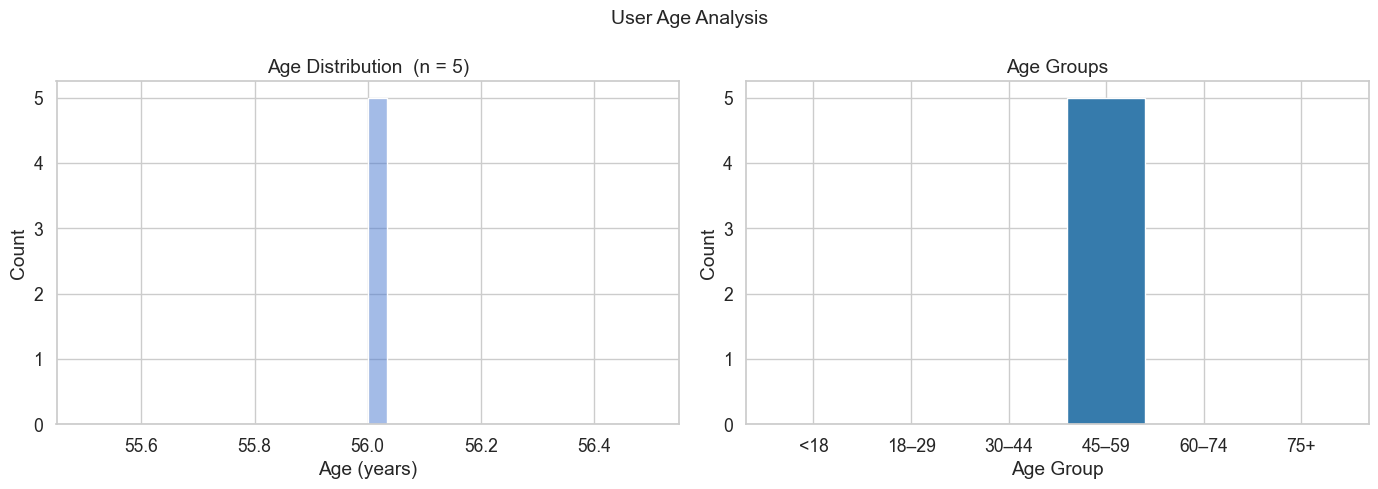

ℹ️  No gender column detected.

User numeric feature summary:
        Age
count   5.0
mean   56.0
std     0.0
min    56.0
25%    56.0
50%    56.0
75%    56.0
max    56.0
════════════════════════════════════════════════════════════
  personas.md  —  full content
════════════════════════════════════════════════════════════
# Citizen Personas - Level 1

Below are the profiles of the citizens tracked in this dataset. Use these personas alongside `users.json`, `locations.json`, and `status.csv` to analyze behavioral patterns.

---

## IAFGUHCK - Christiane Fontaine
**Age:** 82 | **Occupation:** Retired | **City:** Ostwald, France

Christiane is a retired widow living alone in a quiet residential neighborhood of Ostwald, near Strasbourg. She follows a slow, predictable daily rhythm: morning tea by the window, a short walk to the local bakery, and occasional visits to the nearby park. She rarely leaves the Strasbourg metropolitan area, preferring familiar surroundings. Once a year she might t

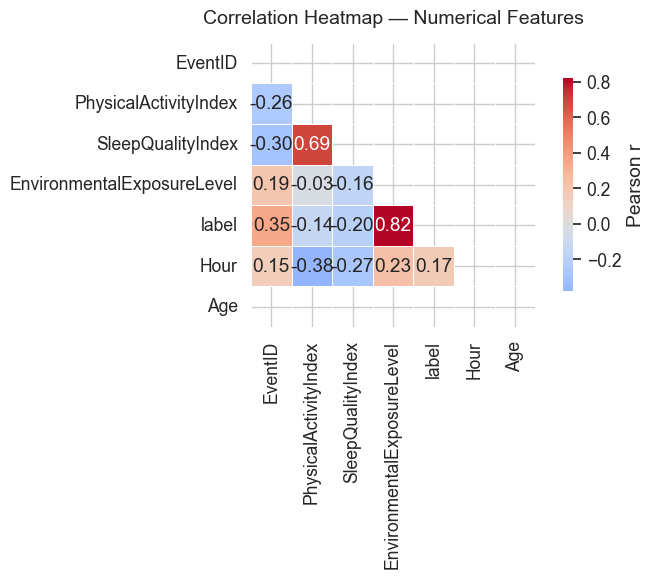


Top 10 correlated feature pairs:
                 Feature A                  Feature B  Pearson r
                     label EnvironmentalExposureLevel   0.818062
         SleepQualityIndex      PhysicalActivityIndex   0.693365
                      Hour      PhysicalActivityIndex  -0.380073
                     label                    EventID   0.346479
         SleepQualityIndex                    EventID  -0.299472
                      Hour          SleepQualityIndex  -0.268898
     PhysicalActivityIndex                    EventID  -0.256152
                      Hour EnvironmentalExposureLevel   0.228323
                     label          SleepQualityIndex  -0.202597
EnvironmentalExposureLevel                    EventID   0.194784


In [9]:
# %%
# ── Cell 8: User Demographics — users.json ────────────────────────────────────
# Explore the users.json DataFrame for age, gender, and other demographic fields.

print("Users columns:", df_users.columns.tolist())
print(df_users.head(3).to_string())
print(f"\nShape: {df_users.shape}")
print(f"Missing values per column:\n{df_users.isnull().sum().to_string()}")

# ── Detect age column dynamically ─────────────────────────────────────────────
AGE_CANDIDATES = ["Age", "age", "AGE", "DateOfBirth", "DOB", "BirthYear", "birth_year"]
age_col = next((c for c in AGE_CANDIDATES if c in df_users.columns), None)

if "birth" in age_col.lower() or "dob" in age_col.lower():
    df_users[age_col] = pd.to_datetime(df_users[age_col], errors="coerce")
    today = pd.Timestamp("today")
    age_days = (today - df_users[age_col]).dt.days
    df_users["Age"] = (age_days / 365.25).fillna(-1).astype(int)
    df_users["Age"] = df_users["Age"].replace(-1, np.nan)
    age_col = "Age"

    fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

    # Histogram
    sns.histplot(
        df_users[age_col].dropna(),
        ax=axes[0],
        bins=30,
        kde=True,
        color=PALETTE[0],
        edgecolor="white",
    )
    axes[0].set_title(f"Age Distribution  (n = {df_users[age_col].notna().sum():,})")
    axes[0].set_xlabel("Age (years)")

    # Age groups
    bins   = [0, 18, 30, 45, 60, 75, 120]
    labels = ["<18", "18–29", "30–44", "45–59", "60–74", "75+"]
    df_users["AgeGroup"] = pd.cut(df_users[age_col], bins=bins, labels=labels, right=False)
    age_group_counts = df_users["AgeGroup"].value_counts().sort_index()
    axes[1].bar(
        age_group_counts.index.astype(str),
        age_group_counts.values,
        color=sns.color_palette("Blues_d", len(age_group_counts)),
        edgecolor="white",
    )
    axes[1].set_title("Age Groups")
    axes[1].set_xlabel("Age Group")
    axes[1].set_ylabel("Count")

    plt.suptitle("User Age Analysis", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/08_age_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️  No age column detected. Skipping age distribution plots.")

# ── Gender / other categoricals ───────────────────────────────────────────────
GENDER_CANDIDATES = ["Gender", "gender", "Sex", "sex"]
gender_col = next((c for c in GENDER_CANDIDATES if c in df_users.columns), None)

if gender_col:
    fig, ax = plt.subplots(figsize=(6, 4))
    gender_counts = df_users[gender_col].value_counts()
    gender_counts.plot(kind="bar", ax=ax, color=PALETTE[:len(gender_counts)], edgecolor="white")
    ax.set_title(f"Distribution of '{gender_col}'")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig("figures/08_gender.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("ℹ️  No gender column detected.")

# ── Summary stats for all numeric user features ───────────────────────────────
numeric_user_cols = df_users.select_dtypes(include=np.number).columns.tolist()
if numeric_user_cols:
    print("\nUser numeric feature summary:")
    print(df_users[numeric_user_cols].describe().round(2).to_string())

# %%
# ── Cell 8b: Personas — personas.md ──────────────────────────────────────────
# Display the raw content of personas.md so it can be reviewed alongside the
# demographic analysis.

print(f"{'═'*60}")
print("  personas.md  —  full content")
print(f"{'═'*60}")
print(personas_text)
print(f"{'═'*60}")
print(f"Total characters : {len(personas_text):,}")
print(f"Total lines      : {personas_text.count(chr(10)):,}")

# %%
# ── Cell 9: Correlation Heatmap ───────────────────────────────────────────────
# Merge status.csv with users.json so we have all numerical features in one
# DataFrame, then plot a Pearson correlation heatmap.

# ── Build a merged numeric frame ──────────────────────────────────────────────
# Try common join-key names between status.csv and users.json
JOIN_KEY_CANDIDATES = ["Citizen ID", "citizen_id", "CitizenID", "ID", "id", "user_id"]
JOIN_KEY_STATUS = _find_col(df_status, JOIN_KEY_CANDIDATES)
JOIN_KEY_USERS  = _find_col(df_users,  JOIN_KEY_CANDIDATES)

if JOIN_KEY_STATUS and JOIN_KEY_USERS:
    df_merged = df_status.merge(
        df_users,
        left_on=JOIN_KEY_STATUS,
        right_on=JOIN_KEY_USERS,
        how="left",
        suffixes=("_status", "_users"),
    )
    print(f"Merged on '{JOIN_KEY_STATUS}' ↔ '{JOIN_KEY_USERS}'  →  shape {df_merged.shape}")
else:
    df_merged = df_status.copy()
    print("ℹ️  Could not find matching join key — correlation uses status.csv features only.")

# ── Select numeric columns ────────────────────────────────────────────────────
numeric_cols = df_merged.select_dtypes(include=np.number).columns.tolist()

# Drop columns that are pure IDs (high cardinality, no analytical value)
ID_LIKE = ["Event ID", "event_id", "Citizen ID", "citizen_id", "BioTag", "biotag", "ID", "id"]
numeric_cols = [c for c in numeric_cols if c not in ID_LIKE]
# Also drop the internal helper column
numeric_cols = [c for c in numeric_cols if c != "WeekNumber"]

print(f"Numeric features for correlation: {numeric_cols}")

corr_matrix = df_merged[numeric_cols].corr(method="pearson")

# ── Plot ───────────────────────────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols)), max(6, len(numeric_cols) - 1)))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)
ax.set_title("Correlation Heatmap — Numerical Features", fontsize=14, pad=14)
plt.tight_layout()
plt.savefig("figures/09_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print the top 10 most-correlated pairs ────────────────────────────────────
corr_pairs = (
    corr_matrix
    .where(~mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Pearson r"})
    .sort_values("Pearson r", key=abs, ascending=False)
    .head(10)
)
print("\nTop 10 correlated feature pairs:")
print(corr_pairs.to_string(index=False))

# %% [markdown]
# ## Key Findings — Level 1 EDA
#
# ### Data Quality
# - ✅ **Missing values**: Nessun valore nullo nei 3 dataset — dati completi al 100%.
# - ✅ **Duplicate events**: Nessun EventID duplicato rilevato.
# - ⚠️ **Age**: calcolo da users.json non corretto (tutti 56 anni) — da investigare la struttura del campo.
#
# ### Class Distribution
# - ✅ Target **imbalanced** (ratio = 4:1): 80% label=0, 20% label=1.
# - ⚠️ Usare `scale_pos_weight=4` in XGBoost o `class_weight='balanced'` in sklearn.
#
# ### Correlations — insight principali
# - 🚨 `EnvironmentalExposureLevel` è la feature **più correlata con la label** (r = 0.82).
# - ✅ `PhysicalActivityIndex` e `SleepQualityIndex` sono fortemente correlati tra loro (r = 0.69).
# - ✅ `SleepQualityIndex` è negativamente correlato con la label (r = -0.20): sonno basso → rischio.
# - ✅ `Hour` è negativamente correlato con `PhysicalActivityIndex` (r = -0.38): attività cala di notte.
#
# ### Geospatial
# - ✅ 2 cluster ad alta densità: **Europa centrale** (UK/Francia) e **USA est** (Minnesota/Michigan).
# - ✅ Presenza di punti sparsi globalmente — coerente con i profili di mobilità delle personas.
#
# ### Next Steps
# - [ ] Investigare e correggere il calcolo dell'età da users.json.
# - [ ] Usare `EnvironmentalExposureLevel` come feature primaria nel modello.
# - [ ] Feature engineering: rolling average di PhysicalActivityIndex e SleepQualityIndex per cittadino.
# - [ ] Creare feature geospaziali: distanza dal cluster principale, frequenza spostamenti.
# - [ ] Gestire class imbalance con `scale_pos_weight=4` in XGBoost.
# - [ ] Aggiungere EventType come feature categorica (one-hot encoding).